In [9]:
import torch
import ad_tools.tools as tools
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt

In [12]:
class BetaVAEMark3Encoder(nn.Module):
    """
    Beta VAE Mark 3 Encoder 
    """
    def __init__(self, latent_dim = 4, log_clamping = True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = 3, padding = (1,0))
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3,padding = (1,0))
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3,padding = (1,0))
        self.pool1 = nn.MaxPool2d(2, return_indices = True)
        self.pool2 = nn.MaxPool2d((5,2), return_indices = True)
        self.pool3 = nn.MaxPool2d((5,2), return_indices = True)
        self.flatten = nn.Flatten(start_dim = 1)
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        self.circular_padding = nn.CircularPad2d((1,1,0,0))
        self.log_clamping = log_clamping


    
    def forward(self, input):
        # Convolutional Block 1
        output1 = self.circular_padding(input)
        output2 = self.conv1(output1)
        output3 = F.leaky_relu(output2)
        output4, indices1 = self.pool1(output3)



        # Convolutional Block 2
        output5 = self.circular_padding(output4)
        output6 = self.conv2(output5)
        output7 = F.leaky_relu(output6)
        output8 , indices2 = self.pool2(output7)



        # Convolutional Block 3
        output9 = self.circular_padding(output8)
        output10 = self.conv3(output9)
        output11 = F.leaky_relu(output10)
        output12, indices3 = self.pool3(output11)



        # Latent space mapping
        output13 = self.flatten(output12)
        mu = self.mu(output13)
        logvar = self.logvar(output13)
        if self.log_clamping:
            pass
        
        return mu, logvar,indices1,indices2,indices3

    
class BetaVAEMark3Decoder(nn.Module):
    """
    Beta VAE Mark 3  Decoder.
    """
    def __init__(self, latent_dim = 4):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 256)
    
        self.unpool1 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv1 = nn.ConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,2))
        


        self.unpool2 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv2 = nn.ConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,2))
        


        self.unpool3 = nn.MaxUnpool2d(kernel_size = 2)
        self.transconv3 = nn.ConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,2))        
        self.circular = nn.CircularPad2d((1,1,0,0))
        
    
    def forward(self, latent_vector,indices1, indices2, indices3):
        output1 = self.linear(latent_vector)
        output2 = F.leaky_relu(output1)
        output3 = torch.reshape(output2, shape = (-1,32,1,8))


        
        # Deconvolution Block 1
        output4 = self.unpool1(output3, indices3)
        output5 = self.circular(output4)
        output6 = self.transconv1(output5)
        output7 = F.leaky_relu(output6)



        # Deconvolution Block2
        output8 = self.unpool2(output7, indices2)
        output9 = self.circular(output8)
        output10 = self.transconv2(output9)
        output11 = F.leaky_relu(output10)



        # Deconvolution Block8
        output12 = self.unpool3(output11,indices1)
        output13 = self.circular(output12)
        output14 = self.transconv3(output13)
        output15 = F.relu(output14)
        return output15
    
class BetaVAEMark3(nn.Module):
    """
    Beta VAE Mark 3.
    """

    def __init__(self, latent_dim = 4, log_clamping = True):
        super().__init__()
        self.encoder = BetaVAEMark3Encoder(latent_dim = latent_dim, log_clamping = log_clamping)
        self.decoder = BetaVAEMark3Decoder(latent_dim = latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar, indices1, indices2, indices3 = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z, indices1, indices2, indices3)
        return output, mu, logvar,z

In [13]:
inputdim = (128,6,50,64)
model = BetaVAEMark3()
summary(model,inputdim)

Layer (type:depth-idx)                   Output Shape              Param #
BetaVAEMark3                             [128, 6, 50, 64]          --
├─BetaVAEMark3Encoder: 1-1               [128, 4]                  --
│    └─CircularPad2d: 2-1                [128, 6, 50, 66]          --
│    └─Conv2d: 2-2                       [128, 8, 50, 64]          440
│    └─MaxPool2d: 2-3                    [128, 8, 25, 32]          --
│    └─CircularPad2d: 2-4                [128, 8, 25, 34]          --
│    └─Conv2d: 2-5                       [128, 16, 25, 32]         1,168
│    └─MaxPool2d: 2-6                    [128, 16, 5, 16]          --
│    └─CircularPad2d: 2-7                [128, 16, 5, 18]          --
│    └─Conv2d: 2-8                       [128, 32, 5, 16]          4,640
│    └─MaxPool2d: 2-9                    [128, 32, 1, 8]           --
│    └─Flatten: 2-10                     [128, 256]                --
│    └─Linear: 2-11                      [128, 4]                  1,028
│    

In [42]:
class BetaVAEMark3_3Encoder(nn.Module):
    """
    Beta VAE Mark 3 Encoder 
    """
    def __init__(self, latent_dim = 16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = 3, padding = (1,0))
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3,padding = (1,0))
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3,padding = (1,0))
        self.pool1 = nn.MaxPool2d(2, return_indices = True)
        self.pool2 = nn.MaxPool2d((5,2), return_indices = True)
        self.pool3 = nn.MaxPool2d((5,2), return_indices = True)
        self.flatten = nn.Flatten(start_dim = 1)
        self.linear1 = nn.Linear(256,128)
        self.linear2  = nn.Linear(128,64)
        self.linear3 = nn.Linear(64,32)
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)
        self.circular_padding = nn.CircularPad2d((1,1,0,0))


    
    def forward(self, input):
        # Convolutional Block 1
        output1 = self.circular_padding(input)
        output2 = self.conv1(output1)
        output3 = F.leaky_relu(output2)
        output4, indices1 = self.pool1(output3)



        # Convolutional Block 2
        output5 = self.circular_padding(output4)
        output6 = self.conv2(output5)
        output7 = F.leaky_relu(output6)
        output8 , indices2 = self.pool2(output7)



        # Convolutional Block 3
        output9 = self.circular_padding(output8)
        output10 = self.conv3(output9)
        output11 = F.leaky_relu(output10)
        output12, indices3 = self.pool3(output11)

        # Convolutional Block 4
        output13 = self.circular_padding(output12)
        output14 = self.conv4(output13)
        output15 = F.leaky_relu(output14)
        output16, indices4 = self.pool4(output15)


        # Latent space mapping
        output17 = self.flatten(output16)
        output18 = self.linear1(output17)
        output18 = F.leaky_relu(output18)
        output19 = self.linear2(output18)
        output19 = F.leaky_relu(output19)
        output20 = self.linear3(output19)
        output21 = F.leaky_relu(output20)
        mu = self.mu(output21)
        logvar = self.logvar(output21)
        
        return mu, logvar,indices1,indices2,indices3, indices4

    
class BetaVAEMark3_3Decoder(nn.Module):
    """
    Beta VAE Mark 3  Decoder.
    """
    def __init__(self, latent_dim = 16):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 256)

        self.unpool0 = nn.MaxUnpool2d(kernel_size = (1,2))
        self.transconv0 = nn.ConvTranspose2d(in_channels = 64 , out_channels = 32 ,kernel_size = 3, padding = (1,2))

        self.unpool1 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv1 = nn.ConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,2))
        


        self.unpool2 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv2 = nn.ConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,2))
        


        self.unpool3 = nn.MaxUnpool2d(kernel_size = 2)
        self.transconv3 = nn.ConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,2))        
        self.circular = nn.CircularPad2d((1,1,0,0))
        
    
    def forward(self, latent_vector,indices1, indices2, indices3, indices4):
        output1 = self.linear(latent_vector)
        output2 = F.leaky_relu(output1)
        output3 = torch.reshape(output2, shape = (-1,64,1,4))


        # Deconvolution Block 0
        output4 = self.unpool0(output3, indices4)
        output5 = self.circular(output4)
        output6 = self.transconv0(output5)
        output7 = F.leaky_relu(output6)

        # Deconvolution Block 1
        output4 = self.unpool1(output7, indices3)
        output5 = self.circular(output4)
        output6 = self.transconv1(output5)
        output7 = F.leaky_relu(output6)



        # Deconvolution Block2
        output8 = self.unpool2(output7, indices2)
        output9 = self.circular(output8)
        output10 = self.transconv2(output9)
        output11 = F.leaky_relu(output10)



        # Deconvolution Block8
        output12 = self.unpool3(output11, indices1)
        output13 = self.circular(output12)
        output14 = self.transconv3(output13)
        output15 = F.relu(output14)
        return output15
    
class BetaVAEMark3_3(nn.Module):
    """
    Beta VAE Mark 3.
    """

    def __init__(self, latent_dim = 16):
        super().__init__()
        self.encoder = BetaVAEMark3_3Encoder(latent_dim= latent_dim)
        self.decoder = BetaVAEMark3_3Decoder(latent_dim=latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar, indices1, indices2, indices3, indices4 = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z, indices1, indices2, indices3, indices4)
        return output, mu, logvar,z

In [43]:
inputsize = (128,6,50,64)
model = BetaVAEMark3_3(latent_dim= 32)

summary(model, inputsize)

Layer (type:depth-idx)                   Output Shape              Param #
BetaVAEMark3_3                           [128, 6, 50, 64]          --
├─BetaVAEMark3_3Encoder: 1-1             [128, 32]                 --
│    └─CircularPad2d: 2-1                [128, 6, 50, 66]          --
│    └─Conv2d: 2-2                       [128, 8, 50, 64]          440
│    └─MaxPool2d: 2-3                    [128, 8, 25, 32]          --
│    └─CircularPad2d: 2-4                [128, 8, 25, 34]          --
│    └─Conv2d: 2-5                       [128, 16, 25, 32]         1,168
│    └─MaxPool2d: 2-6                    [128, 16, 5, 16]          --
│    └─CircularPad2d: 2-7                [128, 16, 5, 18]          --
│    └─Conv2d: 2-8                       [128, 32, 5, 16]          4,640
│    └─MaxPool2d: 2-9                    [128, 32, 1, 8]           --
│    └─CircularPad2d: 2-10               [128, 32, 1, 10]          --
│    └─Conv2d: 2-11                      [128, 64, 1, 8]           18,496
│   

# Tuning

In [4]:
import wandb
sweep_configuration = {"method": "bayes",
                       "metric" : {"goal": "maximize",
                                    "name": "hs_kl_signal_acceptance_rate"},
                        "parameters": {"beta_upper_limit": {"min":0, "max":1}}}
project_name = "my_first_sweep"
sweep_id = wandb.sweep(sweep= sweep_configuration, project = project_name)

train_function = lambda input = None: tools.tune(project_name= project_name, model= BetaVAEMark3())

wandb.agent(sweep_id, function = train_function, count = 20)

Create sweep with ID: crtwusdf
Sweep URL: https://wandb.ai/theeinspanner-ucl/my_first_sweep/sweeps/crtwusdf


wandb: Agent Starting Run: ki0g1ni4 with config:
wandb: 	beta_upper_limit: 0
wandb: Currently logged in as: theeinspanner (theeinspanner-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Starting Training Epoch 1
Starting Training Epoch 2
Starting Training Epoch 3
Starting Training Epoch 4


wandb: Ctrl + C detected. Stopping sweep.


Starting Training Epoch 5

Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/xzcapask/atlas_ad_hllhc/ad_tools/tools.py", line 386, in train
    print(f"Starting Training Epoch {i + 1}")
  File "/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/wandb/sdk/lib/console_capture.py", line 173, in write_with_callbacks
    n = orig_write(s)
  File "/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/ipykernel/iostream.py", line 689, in write
    self._schedule_flush()
  File "/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/ipykernel/iostream.py", line 585, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/ipykernel/iostream.py", line 268, in schedule
    self._event_pipe.send(b"")
  File "/home/xzcapask/atlas_ad_hllhc/env/lib/python3.10/site-packages/zmq/sugar/socket.py", line 698, in send
    return super().send(data, flags=flags, copy=copy, track=track)
  Fi

# Analysis

In [40]:
ggf_latent_codes = np.load("data/model_data/BetaVAEMark3/beta1/latent_vectors/ggF_latent_codes.npy")
hs_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/hs_latent_codes.npy")
vbf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/vbf_latent_codes.npy")
jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/jz0_latent_codes.npy")

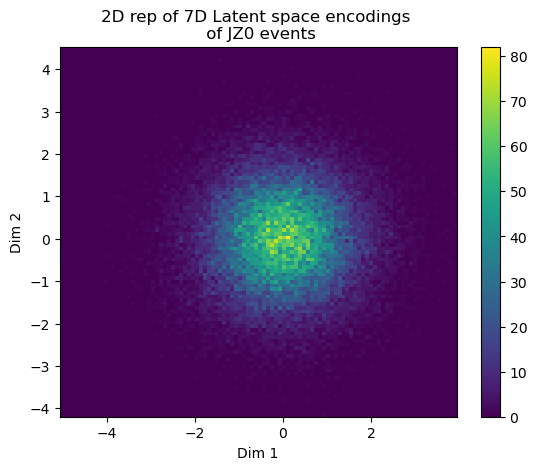

In [41]:
plt.title("2D rep of 7D Latent space encodings \n of JZ0 events")
plt.hist2d(jz0_latent_codes[:,0,0],jz0_latent_codes[:,0,1], bins = 100)
plt.colorbar()
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/JZ0LatentSpace.png")

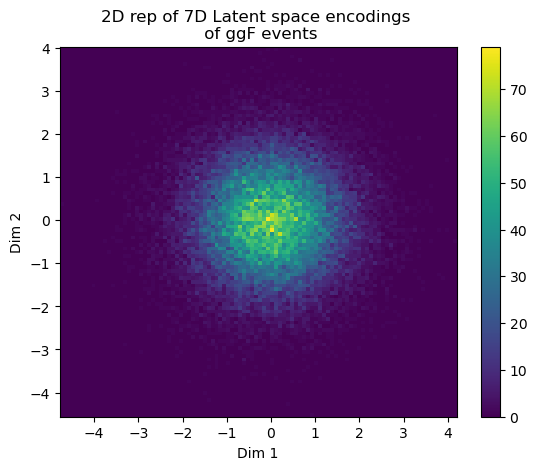

In [42]:
plt.title("2D rep of 7D Latent space encodings \n of ggF events")
plt.hist2d(ggf_latent_codes[:,0,0],ggf_latent_codes[:,0,1], bins = 100)
plt.colorbar()
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/ggFLatentSpace.png")

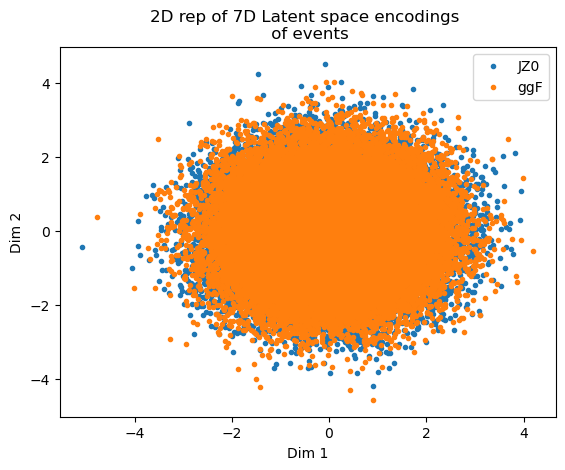

In [43]:
plt.title("2D rep of 7D Latent space encodings \n of events")
plt.plot(jz0_latent_codes[:,0,0],jz0_latent_codes[:,0,1],"." , label = "JZ0")
plt.plot(ggf_latent_codes[:,0,0],ggf_latent_codes[:,0,1],".", label = "ggF" )
plt.legend()
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/jz0ggfLatentSpace.png")

In [42]:
ggf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/ggF_latent_codes.npy")
hs_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/hs_latent_codes.npy")
vbf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/vbf_latent_codes.npy")
jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/jz0_latent_codes.npy")

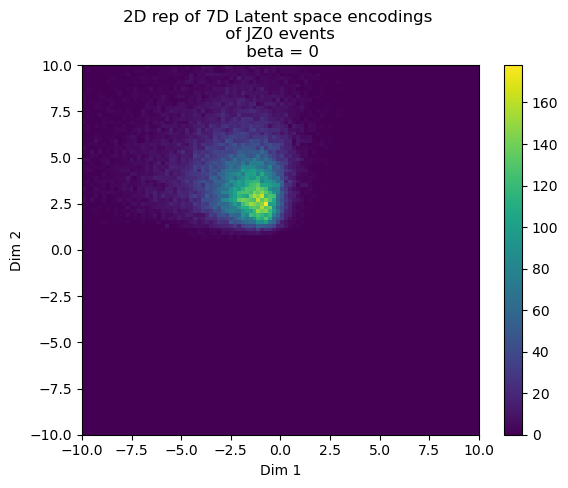

In [34]:
plt.title("2D rep of 7D Latent space encodings \n of JZ0 events \n beta = 0")
plt.hist2d(jz0_latent_codes[:,0,0],jz0_latent_codes[:,0,1], bins = 100, range = [[-10,10],[-10,10]])
plt.colorbar()
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta0/latent_vectors/JZ0LatentSpace.png")

In [33]:
import matplotlib.pyplot as plt

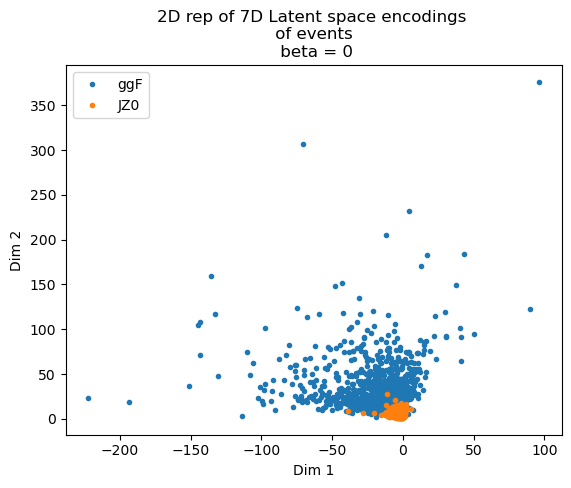

In [41]:
plt.title("2D rep of 7D Latent space encodings \n of events \n beta = 0")

plt.plot(ggf_latent_codes[:1000,0,0],ggf_latent_codes[:1000,0,1],".", label = "ggF" )
plt.plot(jz0_latent_codes[:1000,0,0],jz0_latent_codes[:1000,0,1],"." , label = "JZ0")
#plt.plot(vbf_latent_codes[:1000,0,0],vbf_latent_codes[:1000,0,1],"." , label = "VBF")
#plt.plot(hs_latent_codes[:1000,0,0],hs_latent_codes[:1000,0,1],"." , label = "HS")
plt.legend()
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/latent_vectors/jz0ggfLatentSpace.png")

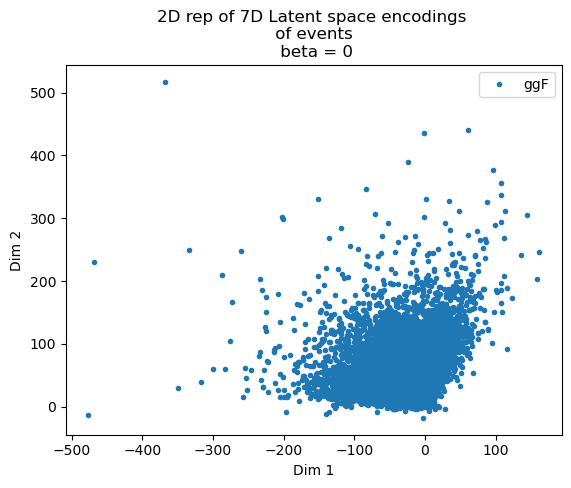

In [38]:
plt.title("2D rep of 7D Latent space encodings \n of events \n beta = 0")
#plt.plot(jz0_latent_codes[:,0,0],jz0_latent_codes[:,0,1],"." , label = "JZ0")
plt.plot(ggf_latent_codes[:,0,0],ggf_latent_codes[:,0,1],".", label = "ggF" )
plt.legend()
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta0/latent_vectors/jz0ggfLatentSpacepart2.png")

vae 3

In [2]:
import numpy as np

In [9]:
np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/signal_acceptance_rates/MSEhssignalrate.npy")

array(49.864, dtype=float32)

In [4]:
np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/signal_acceptance_rates/MSEggFsignalrate.npy")

array(93.882, dtype=float32)

In [11]:
np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/signal_acceptance_rates/KLhssignalrate.npy")

array(1.79, dtype=float32)

In [49]:
ggfmse = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/testing_losses/ggF_mse_losses.npy")

In [52]:
vbfmse = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1/testing_losses/vbf_mse_losses.npy")

In [57]:
msecut = np.load("data/model_data/BetaVAEMark3/beta1/signal_acceptance_rates/MSECutoff.npy")

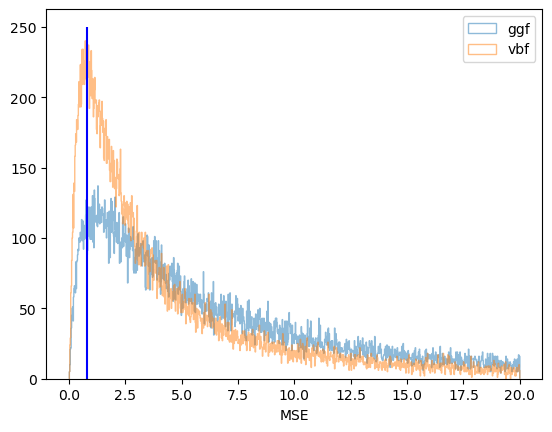

In [71]:
plt.hist(ggfmse, bins = 1000, label = "ggf", range = (0,20), alpha = 0.5, histtype= "step")
plt.hist(vbfmse, bins = 1000, label = "vbf", range = (0,20), alpha = 0.5, histtype= "step")
plt.vlines(msecut,0,250,"b")
plt.xlabel("MSE")
plt.legend()

# Properly trained with kl anneling

In [3]:
ggf_latent_codes = np.load("data/model_data/BetaVAEMark3/beta1freebits/latent_vectors/ggF_latent_codes.npy")
hs_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1freebits/latent_vectors/hs_latent_codes.npy")
vbf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1freebits/latent_vectors/vbf_latent_codes.npy")
jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1freebits/latent_vectors/jz0_latent_codes.npy")

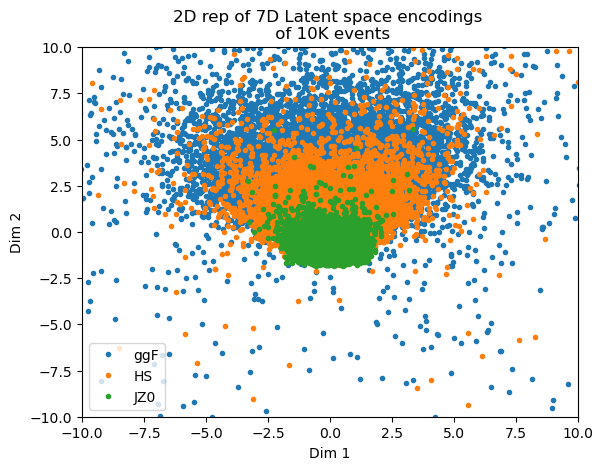

In [23]:
plt.title("2D rep of 7D Latent space encodings \n of 10K events")
plt.plot(ggf_latent_codes[:,0,0],ggf_latent_codes[:,0,1],".", label = "ggF")
#plt.plot(vbf_latent_codes[:,0,0],vbf_latent_codes[:,0,1],".", label = "vbf")
plt.plot(hs_latent_codes[:,0,0],hs_latent_codes[:,0,1],"." , label = "HS")
plt.plot(jz0_latent_codes[:,0,0],jz0_latent_codes[:,0,1],"." , label = "JZ0")

plt.legend()
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/beta1freebits/latent_vectors/jz0ggfLatentSpace.png")